<a href="https://colab.research.google.com/github/sylwiabanasik/Praca_dyplomowa_SGH/blob/main/1_wybor_zmiennych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import bibliotek

In [ ]:
#import library
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import  datasets                          #linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier    #Random Forest
from sklearn.tree import DecisionTreeClassifier        #Decision Tree
from sklearn.linear_model import LogisticRegression    #Logistic Regression
from sklearn.neighbors import KNeighborsClassifier     #KNN

# Import danych i podział na grupe treningowa i testowa

In [ ]:
# import data
wine = datasets.load_wine()
wine.feature_names=['alco', 'mali', 'ash', 'alca', 'magn', 'phen', 'flav', 'nflav', 'proa', 'colo', 'hue', 'od280', 'prol']

In [ ]:
# split data for train and test data
X = preprocessing.StandardScaler().fit(wine.data).transform(wine.data)
y = wine.target
X_train, X_test, y_train, y_test = \
train_test_split(X, y, stratify=wine.target, test_size=0.4, random_state=0)

# Symulacja Random Forest i wybór zmiennych

In [ ]:
# RANDOM FOREST
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train,y_train)

RandomForestClassifier(random_state=0)

Feature  Accuracy RANDOM FOREST


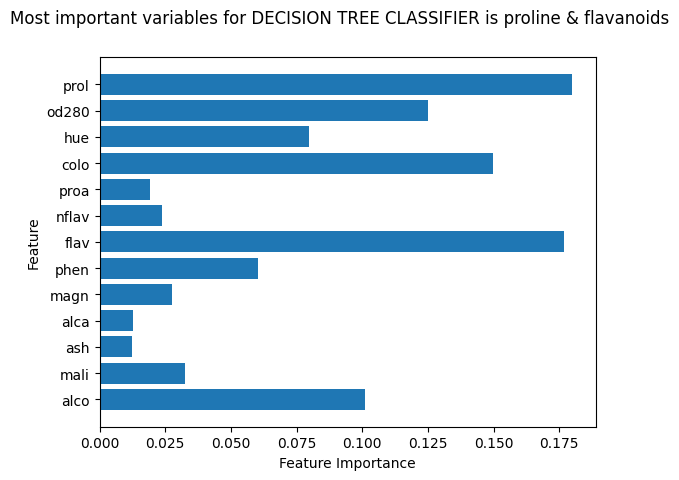

In [ ]:
# Feature Importance for Random FOREST: most important variable is proline & flavanoids
n_feature = wine.data.shape[1]
plt.barh(range(n_feature), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_feature), wine.feature_names)
print('Feature  Accuracy RANDOM FOREST')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.suptitle('Most important variables for DECISION TREE CLASSIFIER is proline & flavanoids')
plt.show()

# Symulacja Drzewa Decyzyjnego i wybór zmiennych

In [ ]:
# DECISION TREE CLASSIFIER
tree = DecisionTreeClassifier(max_depth=5,random_state=0)
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=0)

Feature  Accuracy DECISION TREE CLASSIFIER


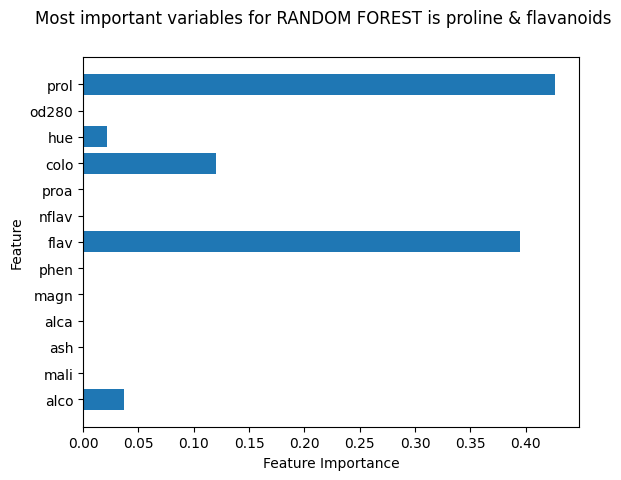

In [ ]:
# Feature Importance for Decision Tree Classifier: most important variable is proline & flavanoids
n_feature = wine.data.shape[1]
plt.barh(range(n_feature), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_feature), wine.feature_names)
print('Feature  Accuracy DECISION TREE CLASSIFIER')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.suptitle('Most important variables for RANDOM FOREST is proline & flavanoids')
plt.show()

# Symulacja Regresji Logistycznej i wybór zmiennych

In [ ]:
# lOGISTIC REGRESSION
log_reg = LogisticRegression(solver ='newton-cg')
log_reg.fit(X_train,y_train)

LogisticRegression(solver='newton-cg')

In [ ]:
log_reg.fit(wine.data, wine.target)
#rfe = RFE(log_reg, 2)
rfe = RFE(estimator = log_reg, n_features_to_select=2)#, step=1, verbose=0, importance_getter='auto')
rfe = rfe.fit(wine.data, wine.target)

Feature  Accuracy LOGISTIC REGRESSION


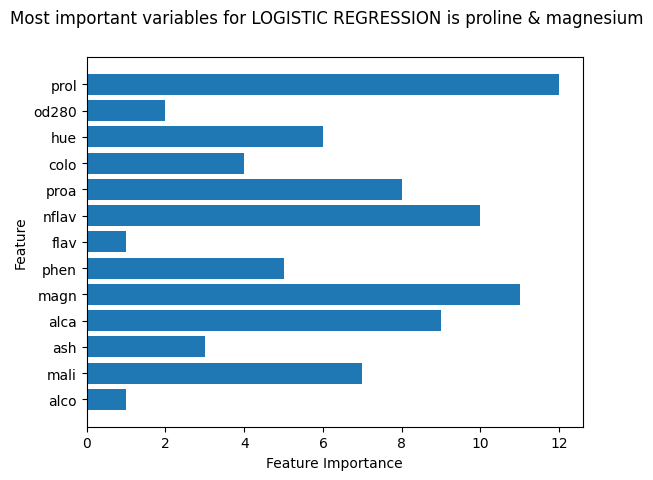

In [ ]:
#     Feature Importance for LOGISTIC REGRESSION: most important variable is alcohol & magnesium
n_feats = wine.data.shape[1]
plt.barh(range(n_feature), rfe.ranking_, align='center')
plt.yticks(np.arange(n_feats), wine.feature_names)
print('Feature  Accuracy LOGISTIC REGRESSION')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.suptitle('Most important variables for LOGISTIC REGRESSION is proline & magnesium')
plt.show()

# Symulacja KNN sąsiadów i wybor zmiennych

In [ ]:
# KNN CLASSIFIER
clf = KNeighborsClassifier()
X = X_train
y = y_train
n_feats = X_train.shape[1]
Feature_accuracy = []
print('Feature  Accuracy KNN CLASSIFIER')
for i in range(n_feats):
    X = X_train[:, i].reshape(-1, 1)
    scores = cross_val_score(clf, X, y)
    Feature_accuracy.append(scores.mean())
    #print(Feature_accuracy)

Feature  Accuracy KNN CLASSIFIER


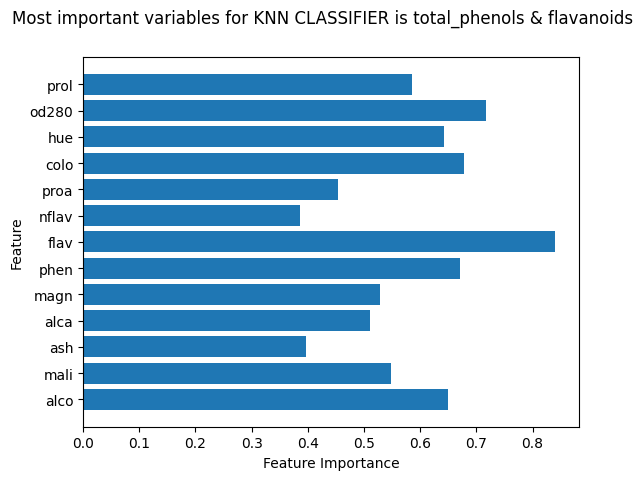

In [ ]:
#     Feature Importance for KNN CLASSIFIER: most important variable is alcohol & flavanoids
plt.barh(range(n_feats), Feature_accuracy, align='center')
plt.yticks(np.arange(n_feats), wine.feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.suptitle('Most important variables for KNN CLASSIFIER is total_phenols & flavanoids')
plt.show()

# Zebranie wniosków z przeprowadzonych symulacji


Feature Importance for Random FOREST: most important variable is proline & flavanoids

Feature Importance for Decision Tree Classifier: most important variable is proline & flavanoids

Feature Importance for lOGISTIC REGRESSION: most important variable is alcohol & flavanoids

Feature Importance for KNN CLASSIFIER: most important variable is total_phenols & flavanoids

Dla modelu RANDOM FOREST & DECISION TREE najlepszy zestaw 2 zmiennych to proline & flavanoids, a dla modelu lOGISTIC REGRESSION & KNN CLASSIFIER to alcohol & flavanoids
na dalszą czesc pracy zakladam, że najlepszym zestawem zmiennych jest alcohol & flavanoids